In [5]:
import pandas as pd

train = pd.read_csv("train.csv",  low_memory=False)
store = pd.read_csv("store.csv")

df = train.merge(store, on='Store', how='left')

In [6]:
df['Date'] = pd.to_datetime(df['Date'])

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017209 non-null  int64         
 1   DayOfWeek                  1017209 non-null  int64         
 2   Date                       1017209 non-null  datetime64[ns]
 3   Sales                      1017209 non-null  int64         
 4   Customers                  1017209 non-null  int64         
 5   Open                       1017209 non-null  int64         
 6   Promo                      1017209 non-null  int64         
 7   StateHoliday               1017209 non-null  object        
 8   SchoolHoliday              1017209 non-null  int64         
 9   StoreType                  1017209 non-null  object        
 10  Assortment                 1017209 non-null  object        
 11  CompetitionDistance        1014567 no

In [8]:
df['Sales'].describe()

count    1.017209e+06
mean     5.773819e+03
std      3.849926e+03
min      0.000000e+00
25%      3.727000e+03
50%      5.744000e+03
75%      7.856000e+03
max      4.155100e+04
Name: Sales, dtype: float64

In [9]:
df['Open'].value_counts()

Open
1    844392
0    172817
Name: count, dtype: int64

In [10]:
df.groupby('Open')['Sales'].mean()

Open
0       0.000000
1    6955.514291
Name: Sales, dtype: float64

In [11]:
df.groupby('Promo')['Sales'].mean()

Promo
0    4406.050805
1    7991.152046
Name: Sales, dtype: float64

In [12]:
df_open = df[df['Open'] == 1].copy()

df_open.shape

(844392, 18)

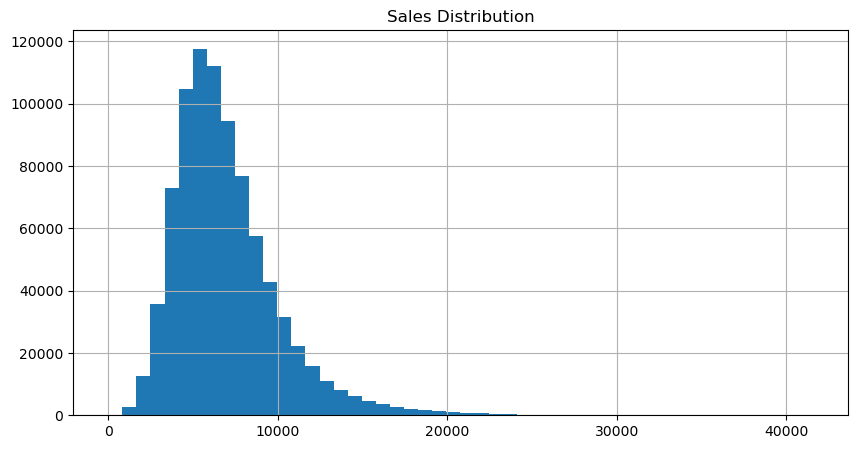

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
df_open['Sales'].hist(bins=50)
plt.title("Sales Distribution")
plt.show()

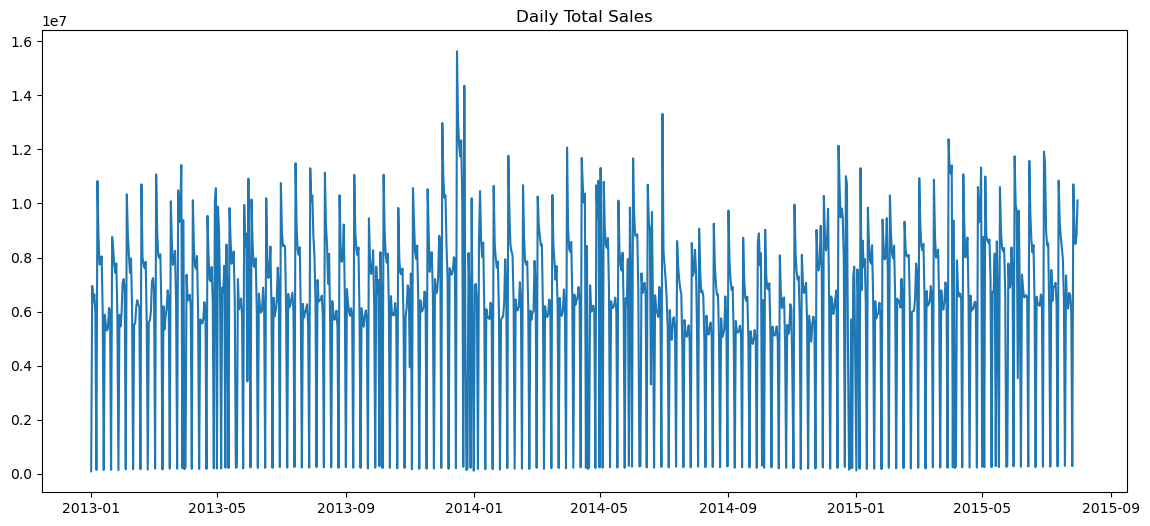

In [14]:
daily_sales = (
    df_open.groupby('Date')['Sales']
    .sum()
    .reset_index()
)

plt.figure(figsize=(14,6))
plt.plot(daily_sales['Date'], daily_sales['Sales'])
plt.title("Daily Total Sales")
plt.show()

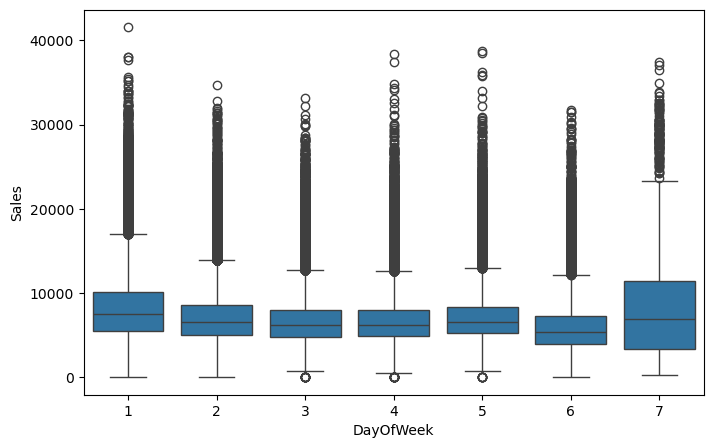

In [15]:
import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(
    x='DayOfWeek',
    y='Sales',
    data=df_open
)
plt.show()

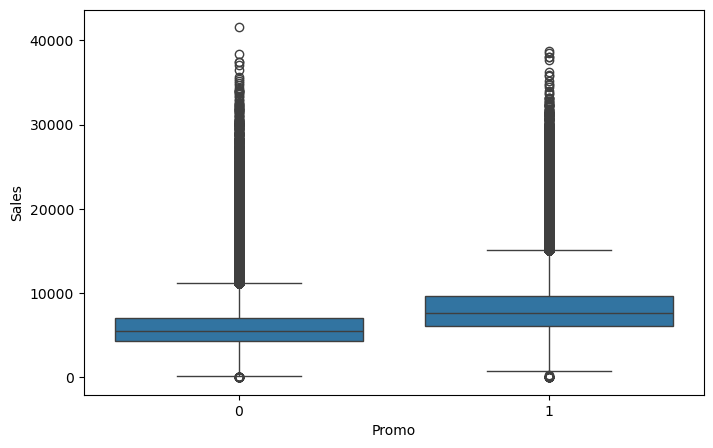

In [16]:
plt.figure(figsize=(8,5))
sns.boxplot(
    x='Promo',
    y='Sales',
    data=df_open
)
plt.show()

In [17]:
df_open.isnull().sum().sort_values(ascending=False)

PromoInterval                423307
Promo2SinceYear              423307
Promo2SinceWeek              423307
CompetitionOpenSinceYear     268619
CompetitionOpenSinceMonth    268619
CompetitionDistance            2186
DayOfWeek                         0
Promo2                            0
Assortment                        0
Store                             0
SchoolHoliday                     0
StateHoliday                      0
Promo                             0
Open                              0
Customers                         0
Sales                             0
Date                              0
StoreType                         0
dtype: int64

df_open.groupby('Promo2').size()

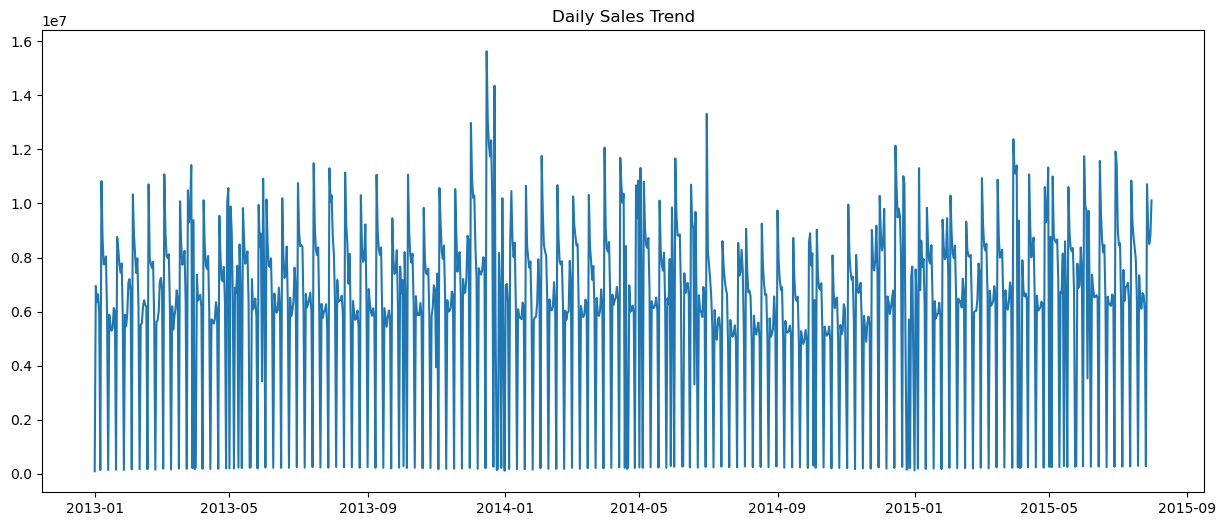

In [18]:
daily_sales = (
    df_open.groupby('Date')['Sales']
    .sum()
    .reset_index()
)

import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))
plt.plot(daily_sales['Date'], daily_sales['Sales'])
plt.title("Daily Sales Trend")
plt.show()

FEATURE ENGINEERING

In [19]:
df_open['Year'] = df_open['Date'].dt.year
df_open['Month'] = df_open['Date'].dt.month
df_open['Week'] = df_open['Date'].dt.isocalendar().week
df_open['Quarter'] = df_open['Date'].dt.quarter
df_open['Day'] = df_open['Date'].dt.day

In [20]:
df_open[['Date','Year','Month','Week','Quarter']].head()

,Date,Year,Month,Week,Quarter
0,2015-07-31,2015,7,31,3
1,2015-07-31,2015,7,31,3
2,2015-07-31,2015,7,31,3
3,2015-07-31,2015,7,31,3
4,2015-07-31,2015,7,31,3


In [21]:
corr_cols = [
    'Sales',
    'Customers',
    'Promo',
    'SchoolHoliday'
]

df_open[corr_cols].corr()

,Sales,Customers,Promo,SchoolHoliday
Sales,1.000000,0.823597,0.368145,0.038617
Customers,0.823597,1.000000,0.182846,0.024902
Promo,0.368145,0.182846,1.000000,0.028964
SchoolHoliday,0.038617,0.024902,0.028964,1.000000


Customer count had the strongest positive correlation with sales (0.82), indicating customer footfall is a major driver of revenue.

In [22]:
df_open['CompetitionDistance'] = (
    df_open['CompetitionDistance']
    .fillna(df_open['CompetitionDistance'].median())
)


In [23]:
df_open['CompetitionOpenSinceMonth'] = (
    df_open['CompetitionOpenSinceMonth']
    .fillna(0)
)

df_open['CompetitionOpenSinceYear'] = (
    df_open['CompetitionOpenSinceYear']
    .fillna(0)
)

In [24]:
df_open['Promo2SinceWeek'] = (
    df_open['Promo2SinceWeek']
    .fillna(0)
)

df_open['Promo2SinceYear'] = (
    df_open['Promo2SinceYear']
    .fillna(0)
)

df_open['PromoInterval'] = (
    df_open['PromoInterval']
    .fillna('None')
)

In [25]:
df_open = df_open.sort_values(
    ['Store', 'Date']
)

In [26]:
df_open['Sales_Lag_7'] = (
    df_open.groupby('Store')['Sales']
    .shift(7)
)

df_open['Sales_Lag_30'] = (
    df_open.groupby('Store')['Sales']
    .shift(30)
)

In [27]:
df_open['Rolling_Mean_7'] = (
    df_open.groupby('Store')['Sales']
    .transform(
        lambda x:
        x.shift(1).rolling(7).mean()
    )
)

In [28]:
df_open['Rolling_Mean_30'] = (
    df_open.groupby('Store')['Sales']
    .transform(
        lambda x:
        x.shift(1).rolling(30).mean()
    )
)

In [29]:
df_open[['Sales',
         'Sales_Lag_7',
         'Sales_Lag_30',
         'Rolling_Mean_7',
         'Rolling_Mean_30']].head(40)

,Sales,Sales_Lag_7,Sales_Lag_30,Rolling_Mean_7,Rolling_Mean_30
1014980,5530,NaN,NaN,NaN,NaN
1013865,4327,NaN,NaN,NaN,NaN
1012750,4486,NaN,NaN,NaN,NaN
1011635,4997,NaN,NaN,NaN,NaN
1009405,7176,NaN,NaN,NaN,NaN
1008290,5580,NaN,NaN,NaN,NaN
1007175,5471,NaN,NaN,NaN,NaN
1006060,4892,5530.0,NaN,5366.714286,NaN
1004945,4881,4327.0,NaN,5275.571429,NaN
1003830,4952,4486.0,NaN,5354.714286,NaN


In [30]:
df_open.isnull().sum().sort_values(
    ascending=False
).head(15)

Rolling_Mean_30    33450
Sales_Lag_30       33450
Rolling_Mean_7      7805
Sales_Lag_7         7805
Promo2                 0
Day                    0
Quarter                0
Week                   0
Month                  0
Year                   0
PromoInterval          0
Promo2SinceYear        0
Promo2SinceWeek        0
Store                  0
DayOfWeek              0
dtype: int64

In [31]:
df_model = df_open.dropna().copy()

In [32]:
df_model.shape

(810942, 27)

In [33]:
df_model.dtypes

Store                                 int64
DayOfWeek                             int64
Date                         datetime64[ns]
Sales                                 int64
Customers                             int64
Open                                  int64
Promo                                 int64
StateHoliday                         object
SchoolHoliday                         int64
StoreType                            object
Assortment                           object
CompetitionDistance                 float64
CompetitionOpenSinceMonth           float64
CompetitionOpenSinceYear            float64
Promo2                                int64
Promo2SinceWeek                     float64
Promo2SinceYear                     float64
PromoInterval                        object
Year                                  int32
Month                                 int32
Week                                 UInt32
Quarter                               int32
Day                             

In [34]:
from sklearn.preprocessing import LabelEncoder

categorical_cols = [
    'StoreType',
    'Assortment',
    'StateHoliday',
    'PromoInterval'
]

for col in categorical_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col].astype(str))

In [35]:
drop_cols = [
    'Date'
]

X = df_model.drop(
    columns=['Sales'] + drop_cols
)

y = df_model['Sales']

TRAIN/TEST SPLIT

In [36]:
train_data = df_model[
    df_model['Date'] < '2015-01-01'
]

test_data = df_model[
    df_model['Date'] >= '2015-01-01'
]

In [37]:
X_train = train_data.drop(
    columns=['Sales', 'Date']
)

y_train = train_data['Sales']

X_test = test_data.drop(
    columns=['Sales', 'Date']
)

y_test = test_data['Sales']

XG Boost

In [38]:
df_model['Week'] = df_model['Week'].astype(int)
df_model['Year'] = df_model['Year'].astype(int)
df_model['Month'] = df_model['Month'].astype(int)
df_model['Quarter'] = df_model['Quarter'].astype(int)
df_model['Day'] = df_model['Day'].astype(int)

In [39]:
X_train.dtypes.unique()

array([dtype('int64'), dtype('float64'), dtype('int32'), UInt32Dtype()],
      dtype=object)

In [40]:
for col in X_train.columns:
    if str(X_train[col].dtype).startswith("UInt"):
        X_train[col] = X_train[col].astype(int)
        X_test[col] = X_test[col].astype(int)


In [41]:
X_train.dtypes.unique()

array([dtype('int64'), dtype('float64'), dtype('int32')], dtype=object)

In [42]:
train_data = df_model[
    df_model['Date'] < '2015-01-01'
]

test_data = df_model[
    df_model['Date'] >= '2015-01-01'
]

X_train = train_data.drop(
    columns=['Sales', 'Date']
)

y_train = train_data['Sales']

X_test = test_data.drop(
    columns=['Sales', 'Date']
)

y_test = test_data['Sales']

In [43]:
import sklearn
import xgboost

print("sklearn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)

sklearn: 1.6.1
xgboost: 2.1.4


In [44]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

In [46]:
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             gamma=None, grow_policy=None, importance_type=None,
             interaction_constraints=None, learning_rate=0.1, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=100, n_jobs=-1,
             num_parallel_tree=None, random_state=42, ...)

In [48]:
preds = model.predict(X_test)

In [49]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

mae = mean_absolute_error(y_test, preds)

rmse = mean_squared_error(
    y_test,
    preds
) ** 0.5

r2 = r2_score(
    y_test,
    preds
)

print("MAE:", mae)
print("RMSE:", rmse)
print("R²:", r2)

MAE: 553.6525268554688
RMSE: 773.2088576186902
R²: 0.9350623488426208


In [50]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(
    y_test,
    preds
)

print("MAPE:", mape)

MAPE: 136538285408256.0


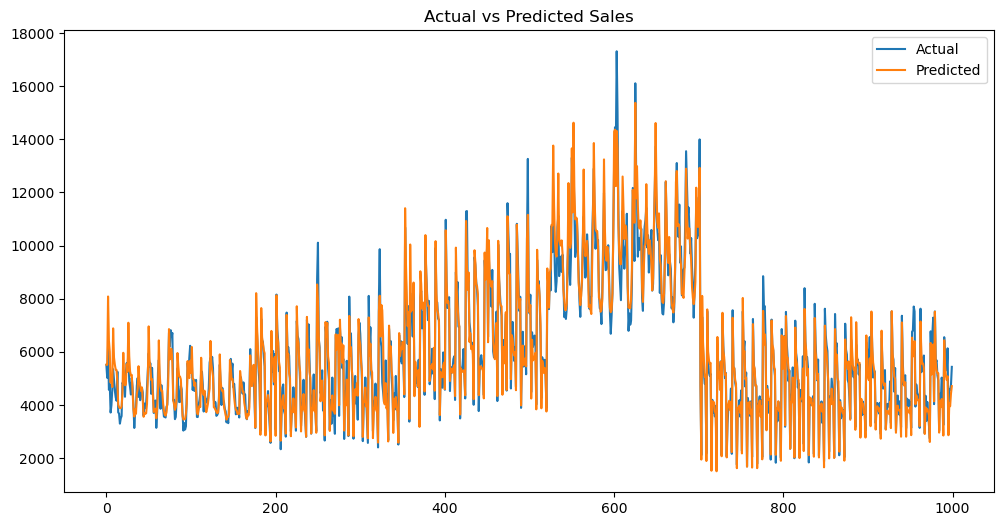

In [51]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    y_test.values[:1000],
    label='Actual'
)

plt.plot(
    preds[:1000],
    label='Predicted'
)

plt.legend()
plt.title("Actual vs Predicted Sales")

plt.show()

In [52]:
(y_test == 0).sum()

np.int64(3)

In [53]:
from sklearn.metrics import mean_absolute_percentage_error

mask = y_test != 0

mape = mean_absolute_percentage_error(
    y_test[mask],
    preds[mask]
)

print("MAPE:", mape)

MAPE: 0.07968982309103012


In [54]:
print(f"MAPE: {mape*100:.2f}%")

MAPE: 7.97%


The model predicted store sales with an average error of 7.97% and achieved an R² score of 0.935 on unseen test data.

SHAP 
(used SHAP to make the model explainable. It helped identify which features contributed most to sales predictions and allowed me to interpret the impact of factors like promotions, customer traffic, and lag-based sales features.)

In [55]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test.sample(5000, random_state=42))

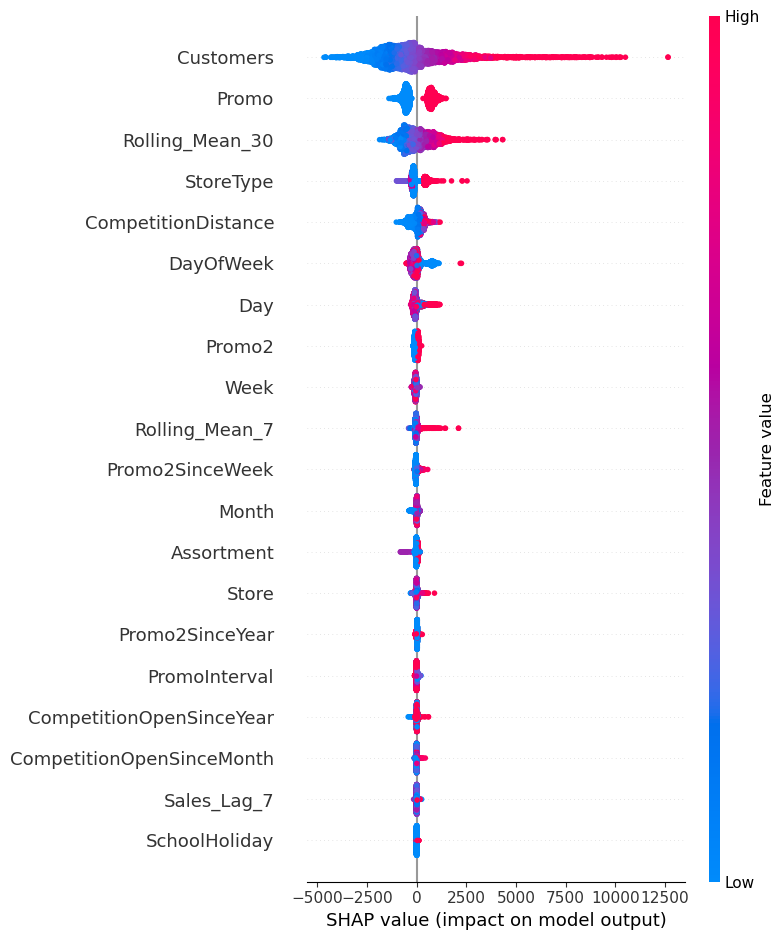

In [56]:
shap.summary_plot(
    shap_values,
    X_test.sample(5000, random_state=42)
)

In [57]:
explainer = shap.TreeExplainer(model)

In [58]:
X_sample = X_test.sample(
    5000,
    random_state=42
)

In [59]:
shap_values = explainer.shap_values(X_sample)

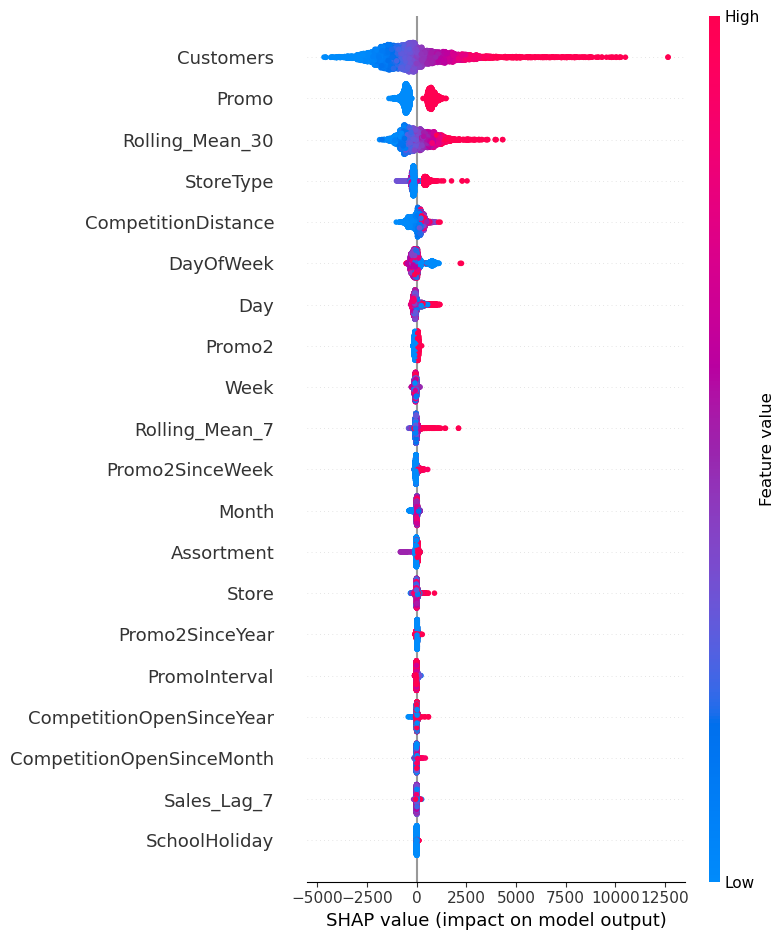

In [60]:
shap.summary_plot(
    shap_values,
    X_sample
)

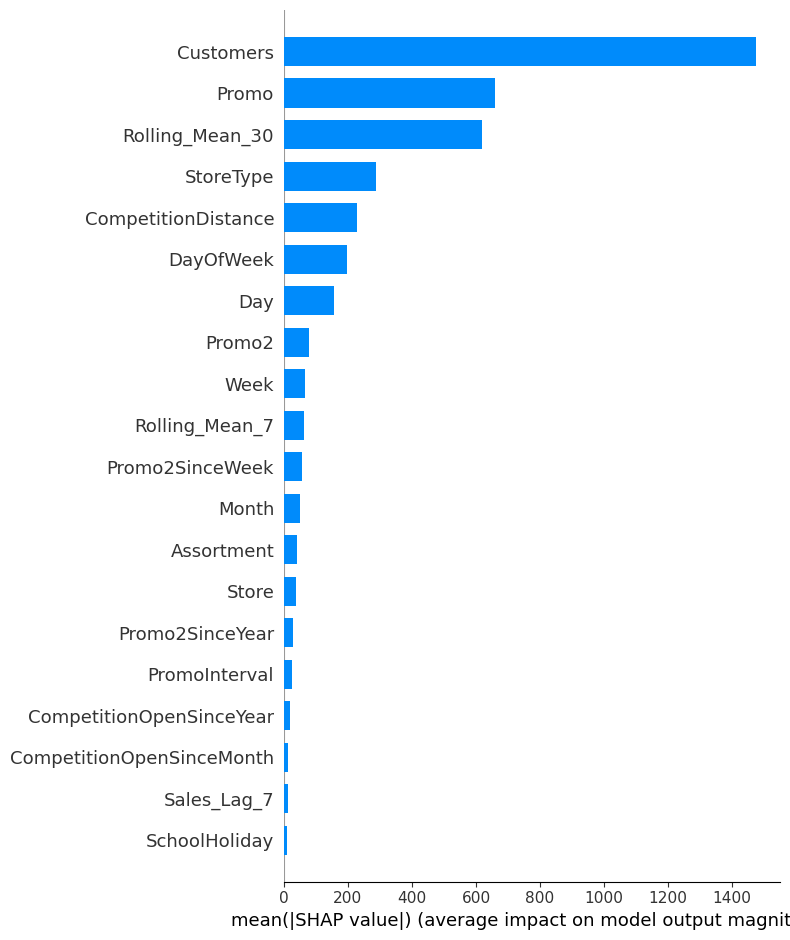

In [61]:
shap.summary_plot(
    shap_values,
    X_sample,
    plot_type="bar"
)

In [62]:
row = X_sample.iloc[[0]]

In [63]:
shap.force_plot(
    explainer.expected_value,
    explainer.shap_values(row),
    row
)

SHAP analysis identified customer traffic, promotional campaigns, and 30-day sales trends as the strongest drivers of store revenue forecasts

In [67]:
#creating a dataframe

results = test_data[['Date','Store']].copy()

results['Actual_Sales'] = y_test.values
results['Predicted_Sales'] = preds

results.head()

,Date,Store,Actual_Sales,Predicted_Sales
234150,2015-01-02,1,5509,5515.407227
233035,2015-01-03,1,5023,5513.753906
230805,2015-01-05,1,6239,8083.285156
229690,2015-01-06,1,4574,6421.137695
228575,2015-01-07,1,4796,6011.844727


In [68]:
results.to_csv('forecast_results.csv', index=False)

In [69]:
df_model.to_csv('retail_forecasting_cleaned.csv', index=False)

In [70]:
sample_df = df_model.sample(100000, random_state=42)
sample_df.to_csv("retail_sample.csv", index=False)